# ADCP Quality Flagging

Quality flagging of minimally processed data. Only processing is removal of data before deployment and adding the transducer's height.

In [2]:
from pathlib import Path
import sys
PROJECT_ROOT = Path.cwd().parents[2]
sys.path.append(str(PROJECT_ROOT))

from mhkit import dolfyn
import xarray as xr
from modules import ADCP as custom
import numpy as np
import matplotlib.pyplot as plt
from mhkit.dolfyn.adp import api

In [ ]:
# loading raw data
ds = dolfyn.load('../../../data/ADCP/S102994A008_Underwater.nc')

In [8]:

ds = ds.rename({v: v.removesuffix("_avg") for v in ds.variables if v.endswith("_avg")})
ds

<xarray.Dataset> Size: 74MB
Dimensions:              (time: 52973, dirIMU: 3, dir: 4, range: 35, beam: 4,
                          earth: 3, inst: 3, q: 4, x1: 4, x2: 4)
Coordinates:
  * time                 (time) datetime64[ns] 424kB 2023-01-13T14:00:00.1259...
  * dirIMU               (dirIMU) <U1 12B 'E' 'N' 'U'
  * dir                  (dir) <U2 32B 'E' 'N' 'U1' 'U2'
  * range                (range) float64 280B 1.5 2.5 3.5 4.5 ... 33.5 34.5 35.5
  * beam                 (beam) int32 16B 1 2 3 4
  * earth                (earth) <U1 12B 'E' 'N' 'U'
  * inst                 (inst) <U1 12B 'X' 'Y' 'Z'
  * q                    (q) <U1 16B 'w' 'x' 'y' 'z'
  * x1                   (x1) int32 16B 1 2 3 4
  * x2                   (x2) int32 16B 1 2 3 4
Data variables: (12/22)
    c_sound              (time) float32 212kB 1.525e+03 1.525e+03 ... 1.518e+03
    temp                 (time) float32 212kB 21.28 21.28 21.28 ... 18.97 18.85
    pressure             (time) float32 212kB 29.69 29.72 29.71 ... 0.205 0.211
    heading              (time) float32 212kB 208.1 208.1 208.1 ... 239.8 237.4
    pitch                (time) float32 212kB 0.66 0.63 0.61 ... -1.27 -0.46
    roll                 (time) float32 212kB -0.69 -0.73 -0.64 ... 1.67 -0.43
    ...                   ...
    orientmat            (earth, inst, time) float32 2MB -0.4717 ... 0.9999
    angrt                (dirIMU, time) float32 636kB 0.0 0.0009766 ... 0.01562
    quaternions          (q, time) float32 848kB 0.5139 0.5141 ... -0.9598
    temp_press           (time) float32 212kB 20.4 20.4 20.4 ... 18.6 18.6 18.6
    xmit_energy          (time) uint16 106kB 492 488 488 488 ... 566 561 561 561
    beam2inst_orientmat  (x1, x2) float32 64B 1.183 0.0 -1.183 ... 0.0 0.5518
Attributes: (12/25)
    burst_config_avg:         {"press_valid": true, "temp_valid": true, "comp...
    n_cells_avg:              35
    coord_sys_axes_avg:       ENU
    n_beams_avg:              4
    ambig_vel_avg:            5.141
    SerialNum_avg:            102994
    ...                       ...
    orientation:              AHRS
    orient_status:            AHRS-3D
    has_imu:                  1
    beam_angle:               25
    rotate_vars:              ['accel_avg', 'angrt_avg', 'mag_avg', 'vel_avg']
    coord_sys:                earth

In [9]:
vel_avg = ds['vel'].mean(dim='range')
principal_heading = dolfyn.calc_principal_heading(vel_avg)
principal_heading

np.float64(163.7592)

### Removing data before/after deployment

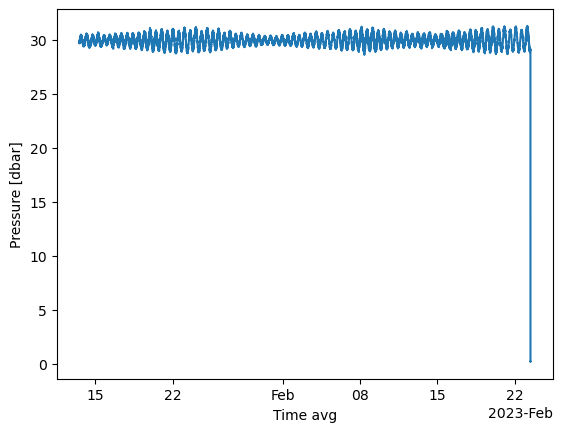

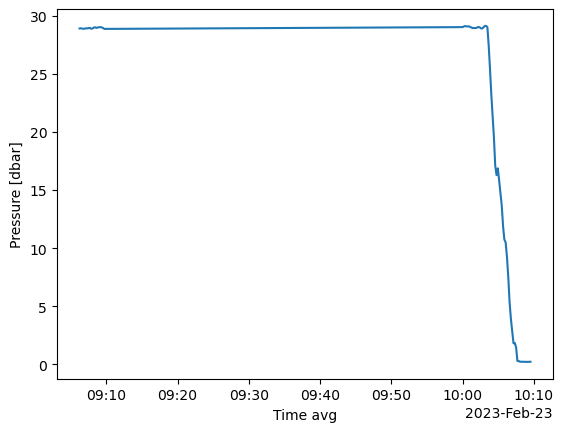

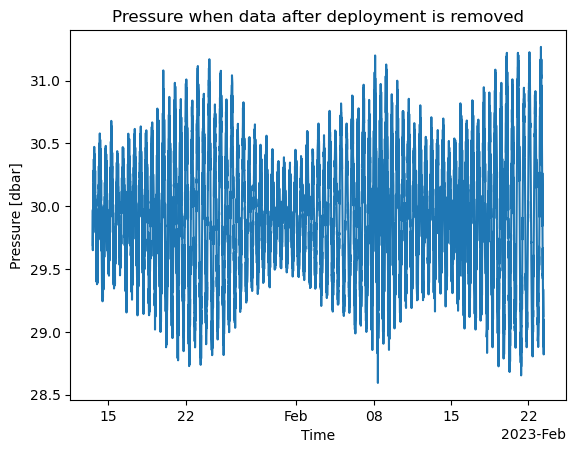

In [10]:
ds.pressure.plot()
plt.show()

ds.pressure.isel(time=slice(52900,52973)).plot()
plt.show()

deployment_end = np.datetime64("2023-02-23T10:00:00") #read off from temperature plot

ds = ds.sel(time=slice(None, deployment_end))

ds.pressure.plot()
plt.title('Pressure when data after deployment is removed')
plt.xlabel('Time')
plt.show()


### Adding the transducers height

In [11]:
print(f"Range values without tranducers height: {ds['range'].values}")

# add 1.4m tranducer height to range and depth
api.clean.set_range_offset(ds, 0.80)

print(f"Range values with tranducers height added: {ds['range'].values}")


Range values without tranducers height: [ 1.5  2.5  3.5  4.5  5.5  6.5  7.5  8.5  9.5 10.5 11.5 12.5 13.5 14.5
 15.5 16.5 17.5 18.5 19.5 20.5 21.5 22.5 23.5 24.5 25.5 26.5 27.5 28.5
 29.5 30.5 31.5 32.5 33.5 34.5 35.5]
Range values with tranducers height added: [ 2.3  3.3  4.3  5.3  6.3  7.3  8.3  9.3 10.3 11.3 12.3 13.3 14.3 15.3
 16.3 17.3 18.3 19.3 20.3 21.3 22.3 23.3 24.3 25.3 26.3 27.3 28.3 29.3
 30.3 31.3 32.3 33.3 34.3 35.3 36.3]


### Define parameters of the specific dataset

In [17]:
# For mask of unrealistic temperature values
T_min=10  # [degree celsius]
T_max=30 # [degree celsius]

# For mask of clock drift
ensamble_interval_min = 11 # [min]
ensamble_interval_ns = ensamble_interval_min*60*10**9
ensamble_interval = np.timedelta64(ensamble_interval_ns, 'ns') # [ns]

# For mask of deployment time wrong
deployment_time = '2023-01-13T14:00:00.125999872' # string YYYY-MM-DDThh:mm:ss

# For mask pressure out of expected interval
depth_expected = 32  # [m]     maximum depth expected
tidal_amplitude_expected = 2.5  # [m]  tidal amplitude expected

# For mask of compass heading devation
heading_expected = 160 # [degrees] clockwise from north

# For using the correct timezome
wintertime = True  # Data is currently in wintertime
# Information for dataset
magnetic_declination_set = False  # No correction for magnetic declination have been set

### Adding quality flags to variables

Numeric flagging arrays are created for corresponding variable, then saved as ancillary variables.

The flagging system includes a primary flag indicating the quality and a secondary flag with a description.

#### Quality flagging temperature

In [18]:
# Creating flagging arrays, default values are (2,2) indicating unknown quality
temp_qc1 = xr.full_like(ds['temp'], 2, dtype=int)        # primary quality flags
temp_qc2 = xr.full_like(ds['temp'], 2, dtype=int)        # secondary quality flags

# Create masks 
# Mask NaNs
mask_NaN_temp = np.isnan(ds['temp'])

# Mask unrealistic temperature values
mask_temp_unrealistic = (ds['temp'] <= T_min) |(ds['temp'] >= T_max)

# Mask temperature spikes
mask_temp_spikes = custom.detect_spikes(ds['temp'],window=192, dim='time', min_periods=3, threshold=3)

# Mask passed all test
mask_temp_passed = (
    ~mask_temp_unrealistic &
    ~mask_temp_spikes &
    ~mask_NaN_temp
    )

# Apply masks to corresponding values to flagging arrays
temp_qc1, temp_qc2 = custom.apply_qc_mask(mask_temp_spikes, (4, 4), temp_qc1, temp_qc2)
temp_qc1, temp_qc2 = custom.apply_qc_mask(mask_temp_unrealistic, (4, 5), temp_qc1, temp_qc2)
temp_qc1, temp_qc2 = custom.apply_qc_mask(mask_NaN_temp, (9, 3), temp_qc1, temp_qc2)
temp_qc1, temp_qc2 = custom.apply_qc_mask(mask_temp_passed, (1, 1), temp_qc1, temp_qc2)

# Add the numeric QC flags
ds['temp_qc_primary'] = temp_qc1.assign_attrs({
    'long_name': 'Quality flags for temperature (primary level)',
    'flag_values': [1, 2, 3, 4, 9],    
    'flag_meanings': 'good unknown potentially_correctable_bad_data bad missing_data',
    'convention': "International Oceanographic Data and Information Exchange Quality Flag Standard",
})

# Add the descriptive QC flags
ds['temp_qc_secondary'] = temp_qc2.assign_attrs({
        'long_name': 'Quality flag descriptions for temperature (secondary level)',
        'flag_values': [1,2,3,4,5],  
        'flag_meanings':
                'passed_all_tests '
                'unknown '
                'missing_data '
                'temperature_spike '
                'unrealistic_temperature ',
        'convention': "International Oceanographic Data and Information Exchange Quality Flag Standard",
    })

# Link as ancillary variables
ds['temp'].attrs['ancillary_variables'] = 'temp_qc_primary temp_qc_secondary'

custom.summarize_qc(ds, 'temp_qc_primary')
custom.summarize_qc(ds, 'temp_qc_secondary')

QC Summary for 'temp_qc_primary':
good: 52915 (99.99%)
unknown: 0 (0.00%)
potentially_correctable_bad_data: 0 (0.00%)
bad: 5 (0.01%)
missing_data: 0 (0.00%)


QC Summary for 'temp_qc_secondary':
passed_all_tests: 52915 (99.99%)
unknown: 0 (0.00%)
missing_data: 0 (0.00%)
temperature_spike: 5 (0.01%)
unrealistic_temperature: 0 (0.00%)




#### Quality flagging time

In [19]:
# Creating flagging arrays, default values are (2,2) indicating unknown quality
time_qc1 = xr.full_like(ds['time'], 2, dtype=int)        # primary quality flags
time_qc2 = xr.full_like(ds['time'], 2, dtype=int)        # secondary quality flags

# Create masks 
# Mask NaNs
mask_NaN_time = np.isnan(ds['time']).astype(bool)

# Mask clock drift
time_diff = np.abs(ds['time'] - ds['time'].shift(time=1)).fillna(ensamble_interval)
# mask where time difference is not following set ensamble interval
mask_clock_drift = ~((time_diff < 11000500000) & (time_diff > 10999500000))

# Mask deployment time wrong
start_time_ds = ds['time'].isel(time=0)

if start_time_ds == np.datetime64(deployment_time):
    mask_time_wrong = xr.full_like(ds['time'], False, dtype=bool)
else:
    mask_time_wrong = xr.full_like(ds['time'], True, dtype=bool)

# Mask passed all tests
mask_time_passed = (
    ~mask_clock_drift &
    ~mask_time_wrong &
    ~mask_NaN_time
)

# Apply masks to corresponding values to flagging arrays

time_qc1, time_qc2 = custom.apply_qc_mask(mask_NaN_time, (9, 3), time_qc1, time_qc2)
time_qc1, time_qc2 = custom.apply_qc_mask(mask_time_wrong, (3, 5), time_qc1, time_qc2)
time_qc1, time_qc2 = custom.apply_qc_mask(mask_clock_drift, (3, 4), time_qc1, time_qc2)
time_qc1, time_qc2 = custom.apply_qc_mask(mask_time_passed, (1, 1), time_qc1, time_qc2)

# Add the numeric QC flags
ds['time_qc_primary'] = time_qc1.assign_attrs({
    'long_name': 'Quality flags for time (primary level)',
    'flag_values': [1, 2, 3, 4, 9],
    'flag_meanings': 'good unknown potentially_correctable_bad_data bad missing_data',
    'convention': "International Oceanographic Data and Information Exchange Quality Flag Standard",
})

# Add the descriptive QC flags
ds['time_qc_secondary'] = time_qc2.assign_attrs({
    'long_name': 'Quality flag descriptions for time (secondary level)',
    'flag_values': [1, 2, 3, 4, 5],
    'flag_meanings':
        'passed_all_tests '
        'unknown '
        'missing_data '
        'clock_drift '
        'deployment_time_wrong ',
    'convention': "International Oceanographic Data and Information Exchange Quality Flag Standard",
})

# Link as ancillary variables
ds['time'].attrs['ancillary_variables'] = 'time_qc_primary time_qc_secondary'

custom.summarize_qc(ds, 'time_qc_primary')
custom.summarize_qc(ds, 'time_qc_secondary')

QC Summary for 'time_qc_primary':
good: 51940 (98.15%)
unknown: 0 (0.00%)
potentially_correctable_bad_data: 980 (1.85%)
bad: 0 (0.00%)
missing_data: 0 (0.00%)


QC Summary for 'time_qc_secondary':
passed_all_tests: 51940 (98.15%)
unknown: 0 (0.00%)
missing_data: 0 (0.00%)
clock_drift: 980 (1.85%)
deployment_time_wrong: 0 (0.00%)




[  10999699712   10999699968   10999800064   10999899904   10999900160
   11000000000   11000099840   11000100096   11000199936   11000300032
   11000300288  660000000000 3016999800064 3016999899904 3016999900160
 3017000000000 3017000099840 3017000100096 3017000199936]


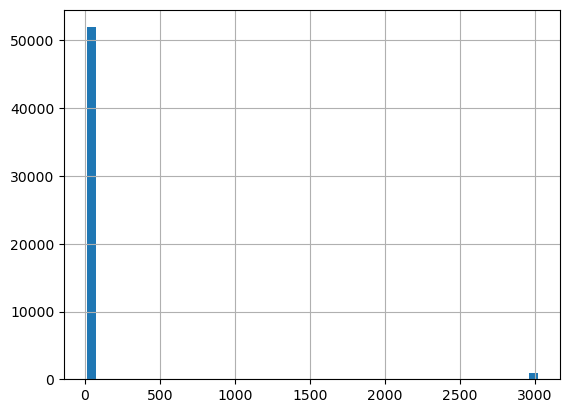

In [20]:
time_diff.to_series().dt.total_seconds().hist(bins=50)

unique_vals = np.unique(time_diff.values)
print(unique_vals)

#### Quality flagging pressure

In [21]:
# Creating flagging arrays, default values are (2,2) indicating unknown quality
pressure_qc1 = xr.full_like(ds['pressure'], 2, dtype=int)        # primary quality flags
pressure_qc2 = xr.full_like(ds['pressure'], 2, dtype=int)        # secondary quality flags

# Creats masks
# Mask NaNs
mask_NaN_pressure = np.isnan(ds['pressure'])

# Mask pressure drift
# Cumulative deviation test
change_point, test_statistic, S = custom.cusum_test(ds['pressure'])
before_change = ds.isel(time=slice(0,change_point))
after_change = ds.isel(time=slice(change_point,-1))

# Apply linear regression before and after potential change
results_before = before_change["pressure"].polyfit(dim='time', deg=1)
slope_before = results_before.polyfit_coefficients.sel(degree=1)
results_after = after_change["pressure"].polyfit(dim='time', deg=1)
slope_after = results_after.polyfit_coefficients.sel(degree=1)

# Compute threshold slope
ns_per_month = 30 * 24 * 60 * 60 * 1e9
slope_tresh = 0.2/(ns_per_month) # corresponds to 0.1 dbar increase per month

mask_pressure_drift = xr.full_like(ds['pressure'], False, dtype=bool)
if abs(slope_before.values) >= slope_tresh:
    mask_pressure_drift[:change_point] = True
elif abs(slope_after.values) >= slope_tresh:
    mask_pressure_drift[change_point:] = True

# Mask constant values
pressure_diff_thresh = 0.001 # allow for rounded values of last digit
mask_pressure_constant = custom.detect_const_pressure(ds, pressure_diff_thresh) # Detects three consecutive constant values

# Mask outside expected interval
mask_pressure_deviation = (
    (ds['pressure'] > depth_expected + tidal_amplitude_expected) |
    (ds['pressure'] < depth_expected - tidal_amplitude_expected)
)

# Mask passed all tests
mask_pressure_passed = (
    ~mask_pressure_drift &
    ~mask_pressure_constant &
    ~mask_pressure_deviation &
    ~mask_NaN_pressure
)

# Apply masks to corresponding values to flagging arrays
pressure_qc1, pressure_qc2 = custom.apply_qc_mask(mask_pressure_deviation, (4, 6), pressure_qc1, pressure_qc2)
pressure_qc1, pressure_qc2 = custom.apply_qc_mask(mask_pressure_drift, (3, 4), pressure_qc1, pressure_qc2)
pressure_qc1, pressure_qc2 = custom.apply_qc_mask(mask_pressure_constant, (4, 5), pressure_qc1, pressure_qc2)
pressure_qc1, pressure_qc2 = custom.apply_qc_mask(mask_NaN_pressure, (9, 3), pressure_qc1, pressure_qc2)
pressure_qc1, pressure_qc2 = custom.apply_qc_mask(mask_pressure_passed, (1, 1), pressure_qc1, pressure_qc2)

# Add the numeric QC flags
ds['pressure_qc_primary'] = pressure_qc1.assign_attrs({
    'long_name': 'Quality flags for pressure (primary level)',
    'flag_values': [1, 2, 3, 4, 9],
    'flag_meanings': 'good unknown potentially_correctable_bad_data bad missing_data',
    'convention': "International Oceanographic Data and Information Exchange Quality Flag Standard",
})

# Add the descriptive QC flags
ds['pressure_qc_secondary'] = pressure_qc2.assign_attrs({
    'long_name': 'Quality flag descriptions for pressure (secondary level)',
    'flag_values': [1, 2, 3, 4, 5, 6],
    'flag_meanings':
        'passed_all_tests '
        'unknown '
        'missing_data '
        'pressure_drift '
        'constant_pressure '
        'pressure_outside_expected_interval ',
    'convention': "International Oceanographic Data and Information Exchange Quality Flag Standard",
})

# Link as ancillary variables
ds['pressure'].attrs['ancillary_variables'] = 'pressure_qc_primary pressure_qc_secondary'

custom.summarize_qc(ds, 'pressure_qc_primary')
custom.summarize_qc(ds, 'pressure_qc_secondary')

QC Summary for 'pressure_qc_primary':
good: 29683 (56.09%)
unknown: 0 (0.00%)
potentially_correctable_bad_data: 14848 (28.06%)
bad: 8389 (15.85%)
missing_data: 0 (0.00%)


QC Summary for 'pressure_qc_secondary':
passed_all_tests: 29683 (56.09%)
unknown: 0 (0.00%)
missing_data: 0 (0.00%)
pressure_drift: 14848 (28.06%)
constant_pressure: 0 (0.00%)
pressure_outside_expected_interval: 8389 (15.85%)




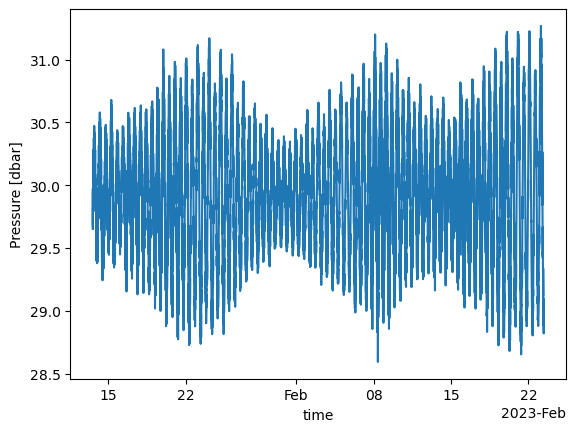

In [18]:
ds['pressure'].plot()
# depth 25 m but pressure in dBar much higher

Change point detected at index: 14848, corresponding to time 2023-01-25T00:09:32.125999872


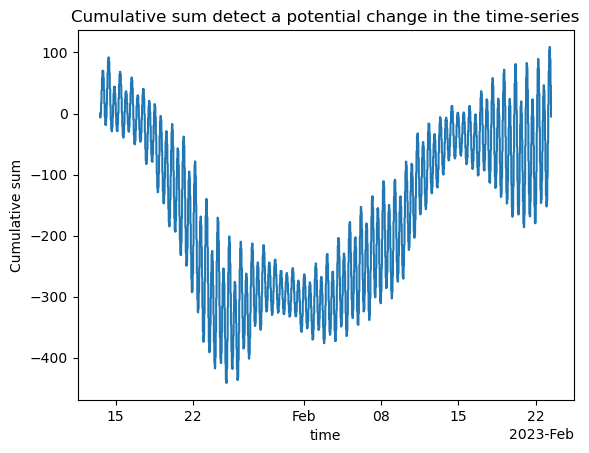

slope of regression before change: -9.213287773653767e-17
slope of regression after change: -5.2645179252460365e-18
slope of threshold of 0.1 dbar/month: 7.71604938271605e-17


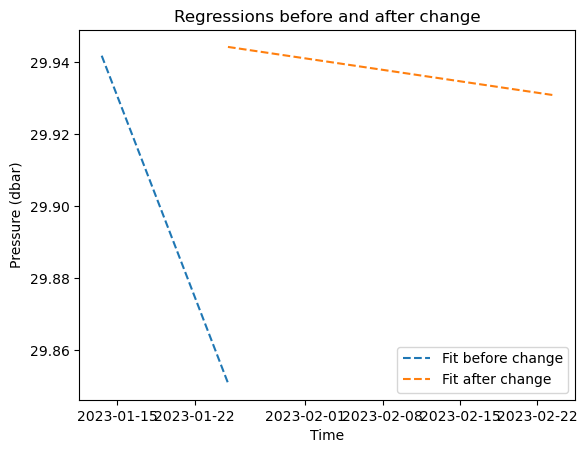

In [19]:
# Summary of pressure drift

print(f"Change point detected at index: {change_point}, corresponding to time {ds["time"][change_point].values}")
S.plot()
plt.ylabel('Cumulative sum')
plt.title('Cumulative sum detect a potential change in the time-series')
plt.show()

print(f"slope of regression before change: {slope_before.values}")
print(f"slope of regression after change: {slope_after.values}")
print(f"slope of threshold of 0.1 dbar/month: {slope_tresh}")

fit_before = xr.polyval(before_change["time"], results_before.polyfit_coefficients)
fit_after = xr.polyval(after_change["time"], results_after.polyfit_coefficients)

# Plot
plt.plot(before_change["time"], fit_before, '--', label="Fit before change")
plt.plot(after_change["time"], fit_after, '--', label="Fit after change")
plt.legend()
plt.xlabel("Time")
plt.ylabel("Pressure (dbar)")
plt.title("Regressions before and after change")
plt.show()

#### Quality flagging compass heading

In [22]:
# Creating flagging arrays, default values are (2,2) indicating unknown quality
heading_qc1 = xr.full_like(ds['heading'], 2, dtype=int)        # primary quality flags
heading_qc2 = xr.full_like(ds['heading'], 2, dtype=int)        # secondary quality flags

# Create masks
# Mask NaNs
mask_NaN_heading = np.isnan(ds['heading'])

# Mask compass heading deviation
heading_thresh = 5
heading_start = ds['heading'].isel(time=0).values
# Calculate absolute angular difference 
heading_diff = ds['heading'] - heading_start
angular_diff = np.abs((heading_diff + 180) % 360 - 180)
# Mask where deviation from start exceeds threshold
mask_heading_deviation = angular_diff > heading_thresh

# Mask compass calibration according to if the principal heading is as expected
vel_avg = ds['vel'].mean(dim='range')
principal_heading = dolfyn.calc_principal_heading(vel_avg)
heading_thresh = 30
mask_compass_wrong = (
    (principal_heading > heading_expected + heading_thresh) |
    (principal_heading < heading_expected - heading_thresh)
)

# Mask passed all tests
mask_heading_passed = (
    ~mask_heading_deviation &
    #~mask_compass_wrong &
    ~mask_NaN_heading
)

# Apply masks to corresponding values to flagging arrays
heading_qc1, heading_qc2 = custom.apply_qc_mask(mask_compass_wrong, (3, 5), heading_qc1, heading_qc2)
heading_qc1, heading_qc2 = custom.apply_qc_mask(mask_heading_deviation, (3, 4), heading_qc1, heading_qc2)
heading_qc1, heading_qc2 = custom.apply_qc_mask(mask_NaN_heading, (9, 3), heading_qc1, heading_qc2)
heading_qc1, heading_qc2 = custom.apply_qc_mask(mask_heading_passed, (1, 1), heading_qc1, heading_qc2)

# Add the numeric QC flags
ds['heading_qc_primary'] = heading_qc1.assign_attrs({
    'long_name': 'Quality flags for heading (primary level)',
    'flag_values': [1, 2, 3, 4, 9],
    'flag_meanings': 'good unknown potentially_correctable_bad_data bad missing_data',
    'convention': "International Oceanographic Data and Information Exchange Quality Flag Standard",
})

# Add the descriptive QC flags
ds['heading_qc_secondary'] = heading_qc2.assign_attrs({
    'long_name': 'Quality flag descriptions for heading (secondary level)',
    'flag_values': [1, 2, 3, 4, 5],
    'flag_meanings':
        'passed_all_tests '
        'unknown '
        'missing_data '
        'compass_heading_deviation '
        'compass_calibration_wrong ',
    'convention': "International Oceanographic Data and Information Exchange Quality Flag Standard",
})

# Link as ancillary variables
ds['heading'].attrs['ancillary_variables'] = 'heading_qc_primary heading_qc_secondary'

custom.summarize_qc(ds, 'heading_qc_primary')
custom.summarize_qc(ds, 'heading_qc_secondary')

QC Summary for 'heading_qc_primary':
good: 52920 (100.00%)
unknown: 0 (0.00%)
potentially_correctable_bad_data: 0 (0.00%)
bad: 0 (0.00%)
missing_data: 0 (0.00%)


QC Summary for 'heading_qc_secondary':
passed_all_tests: 52920 (100.00%)
unknown: 0 (0.00%)
missing_data: 0 (0.00%)
compass_heading_deviation: 0 (0.00%)
compass_calibration_wrong: 0 (0.00%)




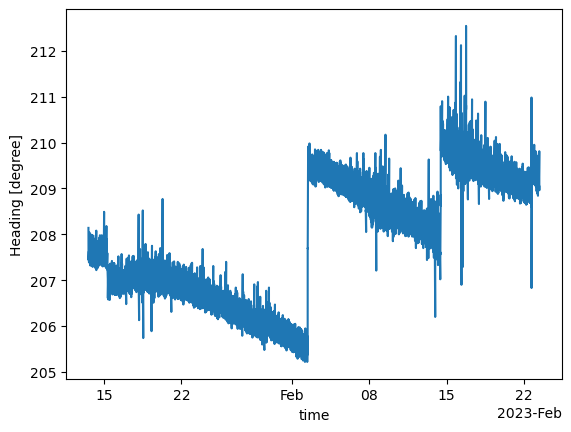

In [23]:
ds['heading'].plot()

#### Quality flagging amplitude

In [30]:
# Creating flagging arrays, default values are (2,2) indicating unknown quality
amp_qc1 = xr.full_like(ds['amp'], 2, dtype=int)        # primary quality flags
amp_qc2 = xr.full_like(ds['amp'], 2, dtype=int)        # secondary quality flags

# Creats masks
# Mask NaNs
mask_NaN_amp = np.isnan(ds['amp'])

# Mask gradient
gradient = custom.rolling_gradient(ds['amp'], dim='range', window=5)
mask_grad = (gradient > 0) | (gradient < -8)

# Mask unrealistic decay
mask_decay = custom.detect_decay_error(ds)

# Mask passed all tests
mask_amp_passed = (
    ~mask_grad &
#    ~mask_decay &
    ~mask_NaN_amp
)

mask_valid_beams = mask_amp_passed.sum(dim='beam') >= 3 # True if 3 or more beams valid
mask_nonvalid_beams = ~mask_valid_beams

# Apply masks to corresponding values to flagging arrays
amp_qc1, amp_qc2 = custom.apply_qc_mask(mask_decay, (4, 5), amp_qc1, amp_qc2)
amp_qc1, amp_qc2 = custom.apply_qc_mask(mask_grad, (4, 4), amp_qc1, amp_qc2)
amp_qc1, amp_qc2 = custom.apply_qc_mask(mask_NaN_amp, (9, 3), amp_qc1, amp_qc2)
amp_qc1, amp_qc2 = custom.apply_qc_mask(mask_amp_passed, (1, 1), amp_qc1, amp_qc2)

# Add the numeric QC flags
ds['amp_qc_primary'] = amp_qc1.assign_attrs({
    'long_name': 'Quality flags for amp (primary level)',
    'flag_values': [1, 2, 3, 4, 9],
    'flag_meanings': 'good unknown potentially_correctable_bad_data bad missing_data',
    'convention': "International Oceanographic Data and Information Exchange Quality Flag Standard",
})

# Add the descriptive QC flags
ds['amp_qc_secondary'] = amp_qc2.assign_attrs({
    'long_name': 'Quality flag descriptions for amp (secondary level)',
    'flag_values': [1, 2, 3, 4, 5],
    'flag_meanings':
        'passed_all_tests '
        'unknown '
        'missing_data '
        'unrealistic_gradient '
        'unrealistic_value ',
    'convention': "International Oceanographic Data and Information Exchange Quality Flag Standard",
})

# Link as ancillary variables
ds['amp'].attrs['ancillary_variables'] = 'amp_qc_primary amp_qc_secondary'

custom.summarize_qc(ds, 'amp_qc_primary')
custom.summarize_qc(ds, 'amp_qc_secondary')

QC Summary for 'amp_qc_primary':
good: 5209918 (70.32%)
unknown: 0 (0.00%)
potentially_correctable_bad_data: 0 (0.00%)
bad: 2198882 (29.68%)
missing_data: 0 (0.00%)


QC Summary for 'amp_qc_secondary':
passed_all_tests: 5209918 (70.32%)
unknown: 0 (0.00%)
missing_data: 0 (0.00%)
unrealistic_gradient: 2198882 (29.68%)
unrealistic_value: 0 (0.00%)




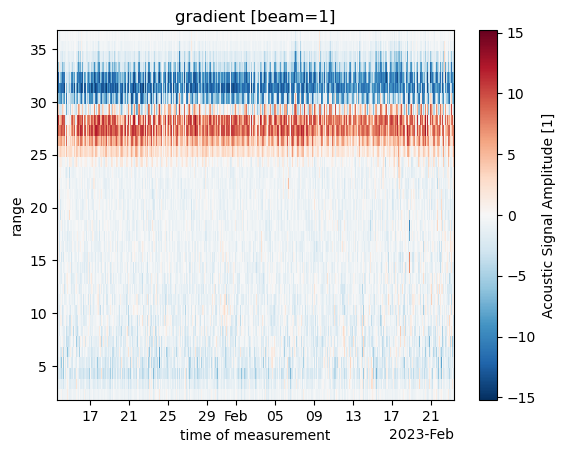

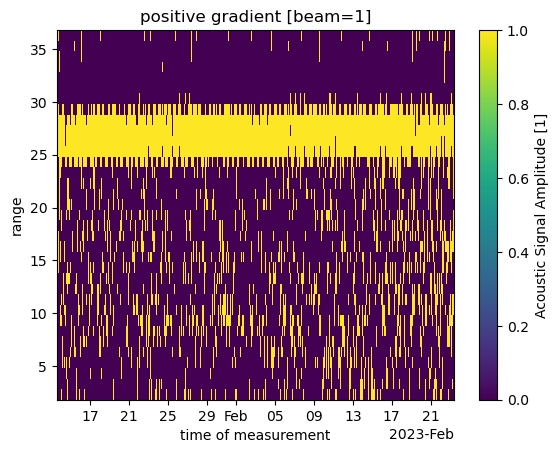

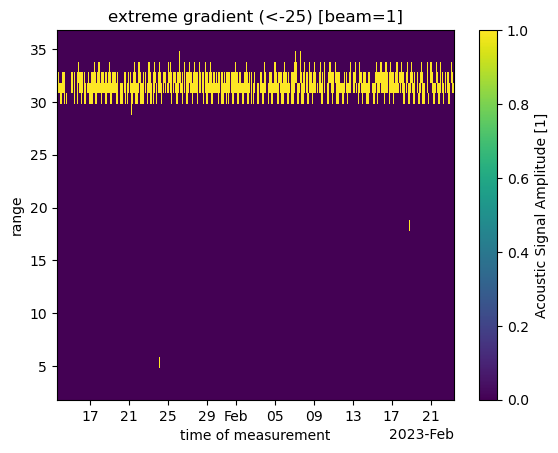

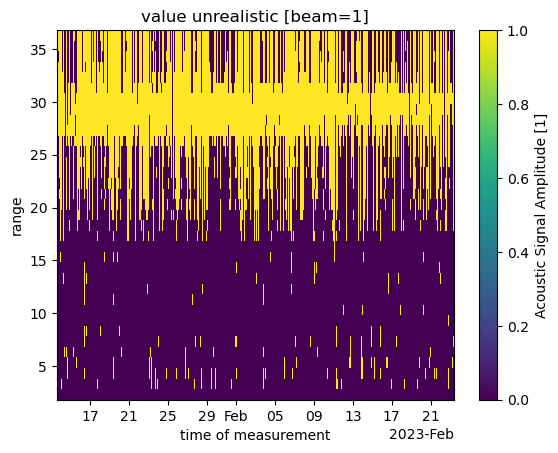

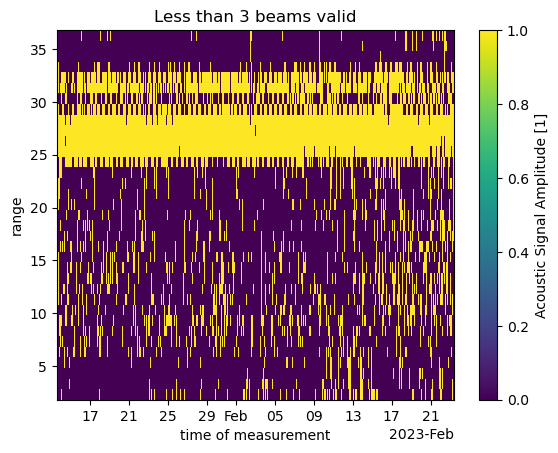

In [31]:
mask_grad_positive = gradient > 0
mask_grad_extreme = gradient < -8


gradient[0].plot()
plt.title('gradient [beam=1]')
plt.show()

mask_grad_positive[0].plot()
plt.title('positive gradient [beam=1]')
plt.show()

mask_grad_extreme[0].plot()
plt.title('extreme gradient (<-25) [beam=1]')
plt.show()

mask_decay[0].plot()
plt.title('value unrealistic [beam=1]')
plt.show()

mask_nonvalid_beams.plot()
plt.title('Less than 3 beams valid')
plt.show()


#### Quality flagging velocity

In [32]:
# Creating flagging arrays, default values are (2,2) indicating unknown quality
qc1 = xr.full_like(ds['vel'], 2, dtype=int)        # primary quality flags
qc2 = xr.full_like(ds['vel'], 2, dtype=int)        # secondary quality flags

# Create masks 
# values above surface
mask_above_surface = ds['range'] > depth_expected - tidal_amplitude_expected

# values below correlation threshold
corr_threshold = 64
mask_below_corr_thresh = ((ds['corr'] <= corr_threshold).sum(dim='beam') >= 2)

# Mask signal amplitude error
mask_nonvalid_beams = ~mask_valid_beams

# NaN values
mask_NaN = np.isnan(ds['vel'])

# compass error
#compass_error = (mask_heading_deviation | mask_compass_wrong)
compass_error = (mask_heading_deviation)

# Mask due to pressure errors within tidal range
pressure_error = (mask_pressure_deviation | mask_pressure_constant | mask_pressure_drift)
HT_max = depth_expected + tidal_amplitude_expected
LT_min = depth_expected - tidal_amplitude_expected
mask_pressure_failure = (
    (ds['range'] >= LT_min) &
    (ds['range'] <= HT_max) &
    pressure_error
)

# time error
time_error = (mask_clock_drift | mask_time_wrong)

# Mask velocity spikes
mask_vel_spikes = custom.detect_spikes(ds['vel'], window=192, dim='time', min_periods=3, threshold=3)

# passed all checks
mask_passed = (
    ~mask_above_surface
    & ~mask_below_corr_thresh
    & ~mask_nonvalid_beams
    & ~mask_NaN
    & ~compass_error
    & ~mask_pressure_failure
    & ~time_error
    & ~mask_vel_spikes
    )
    
masks = {
'above_surface': mask_above_surface,
'below_corr_thresh': mask_below_corr_thresh,
'outlier': mask_nonvalid_beams,
'velocity_spike': mask_vel_spikes,
'compass_error': compass_error,
'pressure_error': mask_pressure_failure,
'time_error': time_error,
'NaN': mask_NaN,
'passed': mask_passed
}

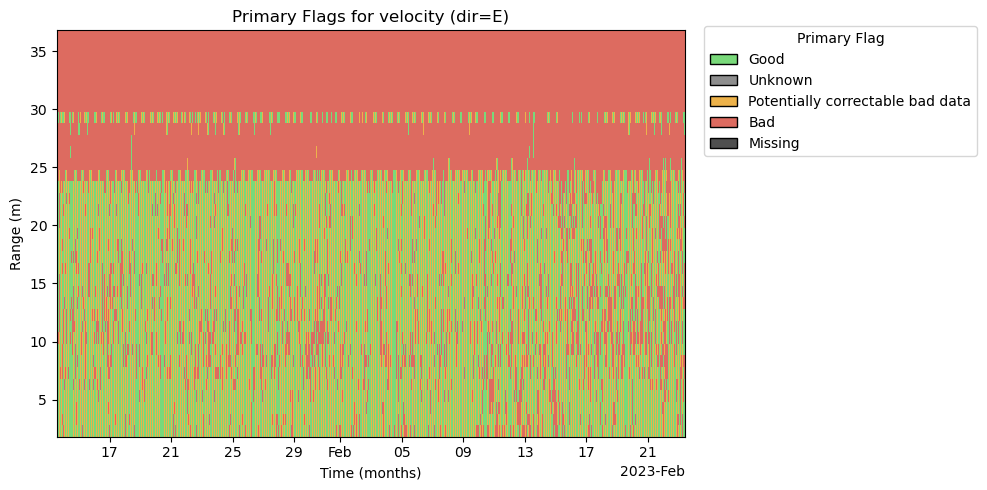

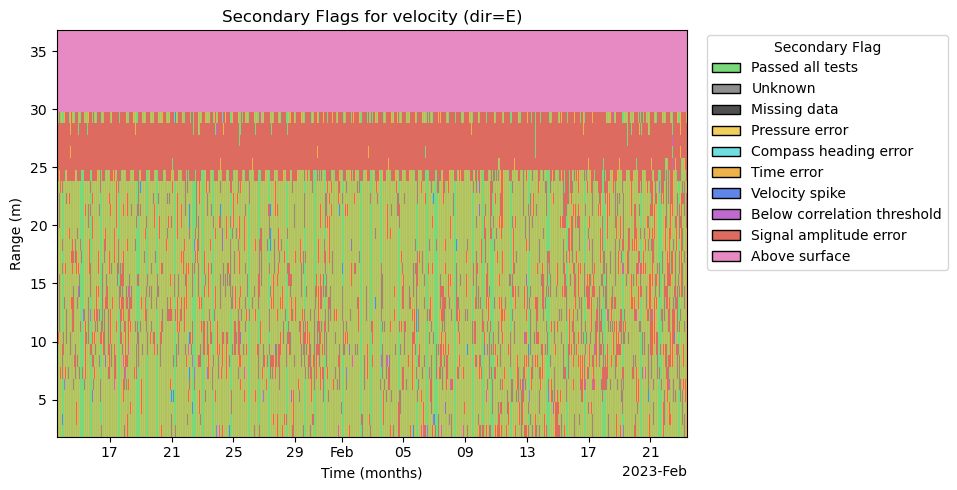

QC Summary for 'vel_qc_primary':
good: 4053999 (54.72%)
unknown: 0 (0.00%)
potentially_correctable_bad_data: 76237 (1.03%)
bad: 3278564 (44.25%)
missing_data: 0 (0.00%)


QC Summary for 'vel_qc_secondary':
passed_all_tests: 4053999 (54.72%)
unknown: 0 (0.00%)
missing_data: 0 (0.00%)
pressure_error: 0 (0.00%)
compass_error: 0 (0.00%)
time_error: 76237 (1.03%)
velocity_spike: 14300 (0.19%)
below_correlation_threshold_64: 19124 (0.26%)
signal_amplitude_outliers: 1763380 (23.80%)
above_surface: 1481760 (20.00%)




In [33]:
# Apply masks to corresponding values to flagging arrays
qc1, qc2 = custom.apply_qc_mask(masks['passed'], (1, 1), qc1, qc2)
qc1, qc2 = custom.apply_qc_mask(masks['NaN'], (9, 3), qc1, qc2)
qc1, qc2 = custom.apply_qc_mask(masks['pressure_error'], (3, 4), qc1, qc2)
qc1, qc2 = custom.apply_qc_mask(masks['compass_error'], (3, 5), qc1, qc2)
qc1, qc2 = custom.apply_qc_mask(masks['time_error'], (3, 6), qc1, qc2)
qc1, qc2 = custom.apply_qc_mask(masks['velocity_spike'], (4, 7), qc1, qc2)
qc1, qc2 = custom.apply_qc_mask(masks['below_corr_thresh'], (4, 8), qc1, qc2)
qc1, qc2 = custom.apply_qc_mask(masks['outlier'], (4, 9), qc1, qc2)
qc1, qc2 = custom.apply_qc_mask(masks['above_surface'], (4, 10), qc1, qc2)


qc1 = qc1.transpose('dir', 'range', 'time')
qc2 = qc2.transpose('dir', 'range', 'time')

# Add the numeric QC flags
ds['vel_qc_primary'] = qc1.assign_attrs({
    'long_name': 'Quality flags for variable (primary level)',
    'flag_values': [1, 2, 3, 4, 9],    
    'flag_meanings': 'good unknown potentially_correctable_bad_data bad missing_data',
    'convention': "International Oceanographic Data and Information Exchange Quality Flag Standard",
})

# Add the descriptive QC flags
ds['vel_qc_secondary'] = qc2.assign_attrs({
        'long_name': 'Quality flag descriptions for variable (secondary level)',
        'flag_values': [1,2,3,4,5,6,7,8,9,10],  
        'flag_meanings':
                'passed_all_tests '
                'unknown '
                'missing_data '
                'pressure_error '
                'compass_error '
                'time_error '
                'velocity_spike '
                'below_correlation_threshold_64 '
                'signal_amplitude_outliers '
                'above_surface ',
        'convention': "International Oceanographic Data and Information Exchange Quality Flag Standard",
    })

# Link as ancillary variables
ds['vel'].attrs['ancillary_variables'] = 'vel_qc_primary vel_qc_secondary'

custom.plot_qc_primary(ds, direction=0)

custom.plot_qc_secondary(ds, direction=0) 

custom.summarize_qc(ds, 'vel_qc_primary')
custom.summarize_qc(ds, 'vel_qc_secondary')

### Adding attributes to daataset

In [34]:
# set to summertime if wintertime == False
if wintertime == False:
    ds['time'] = ds['time'] - np.timedelta64(1, 'h')
    wintertime = True

ds['time'].attrs.update({
    'standard_name': 'time',
    'long_name': 'time of measurement',
    'format': 'YYYY-MM-DDThh:mm:ssZ',
    'timezone': 'UTC',
})

ds.attrs['ensemble_interval'] = f'{ensamble_interval_min} min'

ds.attrs['deployment_start_time'] = deployment_time

ds.attrs['expected_depth'] = depth_expected

ds.attrs['expected_tidal_amplitude'] = tidal_amplitude_expected

ds.attrs['expected_heading'] = heading_expected

In [35]:
ds

<xarray.Dataset> Size: 315MB
Dimensions:                (time: 52920, dirIMU: 3, dir: 4, range: 35, beam: 4,
                            earth: 3, inst: 3, q: 4, x1: 4, x2: 4)
Coordinates:
  * time                   (time) datetime64[ns] 423kB 2023-01-13T14:00:00.12...
  * dirIMU                 (dirIMU) <U1 12B 'E' 'N' 'U'
  * dir                    (dir) <U2 32B 'E' 'N' 'U1' 'U2'
  * range                  (range) float64 280B 2.3 3.3 4.3 ... 34.3 35.3 36.3
  * beam                   (beam) int32 16B 1 2 3 4
  * earth                  (earth) <U1 12B 'E' 'N' 'U'
  * inst                   (inst) <U1 12B 'X' 'Y' 'Z'
  * q                      (q) <U1 16B 'w' 'x' 'y' 'z'
  * x1                     (x1) int32 16B 1 2 3 4
  * x2                     (x2) int32 16B 1 2 3 4
Data variables: (12/34)
    c_sound                (time) float32 212kB 1.525e+03 ... 1.521e+03
    temp                   (time) float32 212kB 21.28 21.28 ... 19.55 19.55
    pressure               (time) float32 212kB 29.69 29.72 ... 28.96 28.88
    heading                (time) float32 212kB 208.1 208.1 ... 209.0 209.0
    pitch                  (time) float32 212kB 0.66 0.63 0.61 ... 0.0 -0.05
    roll                   (time) float32 212kB -0.69 -0.73 ... -0.23 -0.27
    ...                     ...
    heading_qc_primary     (time) int64 423kB 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1
    heading_qc_secondary   (time) int64 423kB 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1
    amp_qc_primary         (beam, range, time) int64 59MB 1 1 1 1 1 ... 4 1 4 1
    amp_qc_secondary       (beam, range, time) int64 59MB 1 1 1 1 1 ... 4 1 4 1
    vel_qc_primary         (dir, range, time) int64 59MB 3 1 1 1 1 ... 4 4 4 4 4
    vel_qc_secondary       (dir, range, time) int64 59MB 6 1 1 1 ... 10 10 10 10
Attributes: (12/32)
    burst_config_avg:          {"press_valid": true, "temp_valid": true, "com...
    n_cells_avg:               35
    coord_sys_axes_avg:        ENU
    n_beams_avg:               4
    ambig_vel_avg:             5.141
    SerialNum_avg:             102994
    ...                        ...
    ensemble_interval:         11 min
    deployment_start_time:     2023-01-13T14:00:00.125999872
    expected_depth:            32
    expected_tidal_amplitude:  2.5
    expected_heading:          160
    complex_vars:              []

### Save flagged data

In [ ]:
dolfyn.save(ds, '../../../data/ADCP/S102994A008_Underwater_flagged.nc')    